In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
base = pd.read_csv('../data/raw/default_of_credit_card_clients.csv' , sep=';', header=1)

In [4]:
base.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
base.shape
base.info()
base.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
# Verificar valores nulos e duplicados
base.isnull().sum()
base.duplicated().sum()


np.int64(0)

In [7]:
# Mudar o nome da Variável Alvo
base.rename(columns={'default payment next month': 'default'}, inplace=True)

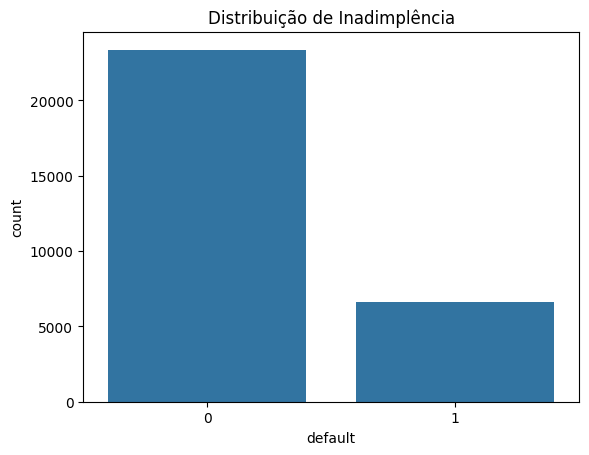

In [8]:
# Analisar as Inadimplências
sns.countplot(x='default', data=base)
plt.title('Distribuição de Inadimplência')
plt.savefig('../imagens/distribuicao_inadimplencia.png')
plt.show()


In [9]:
base['default'].value_counts(normalize=True)

default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

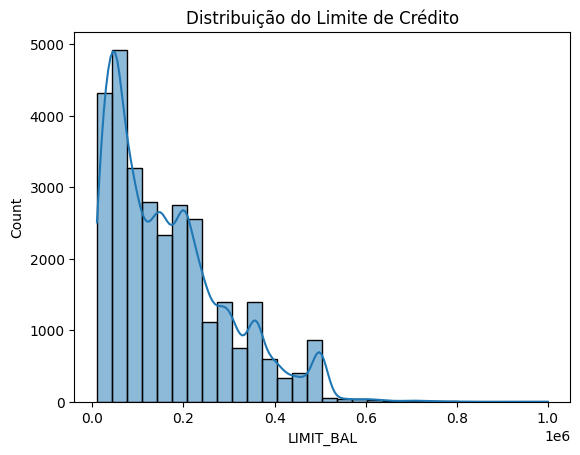

In [10]:
# Analisar a Variavel financeira principal
sns.histplot(base["LIMIT_BAL"], bins=30, kde=True)
plt.title('Distribuição do Limite de Crédito')
plt.savefig('../imagens/distribuicao_limite_credito.png')
plt.show()

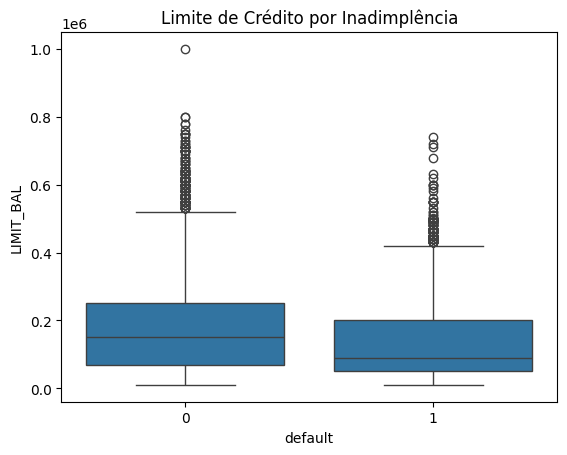

In [11]:
# Verificar a Relação entre o Limite de Crédito e a Inadimplência
sns.boxplot(x='default', y='LIMIT_BAL', data=base)
plt.title('Limite de Crédito por Inadimplência')
plt.savefig('../imagens/boxplot_limite_credito_inadimplencia.png')
plt.show()

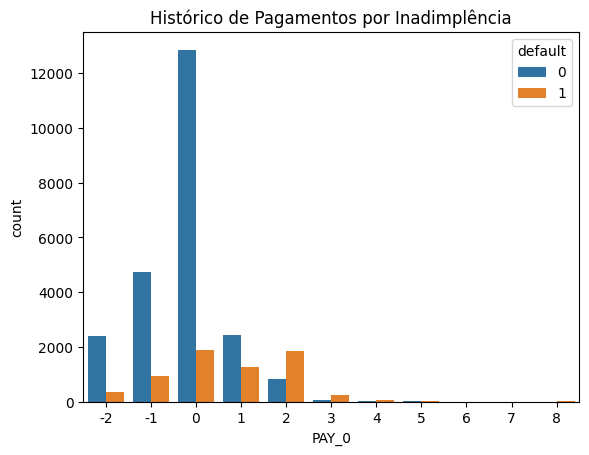

In [15]:
# Verificar o Histórico de Pagamentos
sns.countplot(x='PAY_0', hue='default', data=base)
plt.title('Histórico de Pagamentos por Inadimplência')
plt.savefig('../imagens/historico_pagamentos_inadimplencia.png')
plt.show()

In [16]:
# Separando os Inadimplentes para Análise
inad = base[base['default'] == 1]
nao_inad = base[base['default'] == 0]

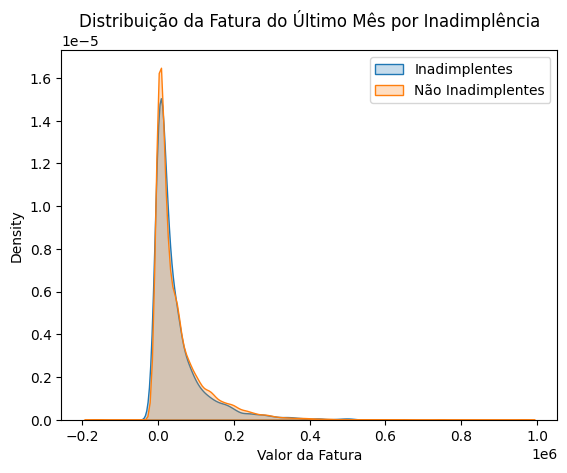

In [17]:
# Fatura por Inadimplência
sns.kdeplot(inad['BILL_AMT1'], label='Inadimplentes', fill=True)
sns.kdeplot(nao_inad['BILL_AMT1'], label='Não Inadimplentes', fill=True)
plt.title('Distribuição da Fatura do Último Mês por Inadimplência')
plt.xlabel('Valor da Fatura')
plt.legend()
plt.savefig('../imagens/distribuicao_fatura_inadimplencia.png')
plt.show()

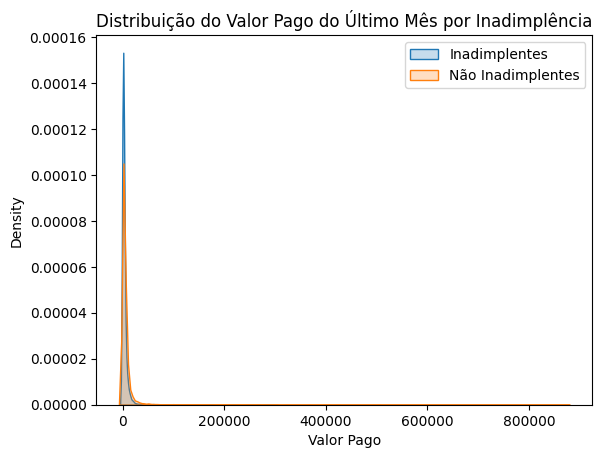

In [18]:
# Analisando Pagamentos por Inadimplência
sns.kdeplot(inad['PAY_AMT1'], label='Inadimplentes', fill=True)
sns.kdeplot(nao_inad['PAY_AMT1'], label='Não Inadimplentes', fill=True)
plt.title('Distribuição do Valor Pago do Último Mês por Inadimplência')
plt.xlabel('Valor Pago')
plt.legend()
plt.savefig('../imagens/distribuicao_pagamento_inadimplencia.png')
plt.show()

In [19]:
# Diferenca entre o Valor da Fatura e o Valor Pago
base['saldo_recente'] = base['BILL_AMT1'] - base['PAY_AMT1']


In [20]:
# Recriando o DataFrame com a nova variável
inad = base[base['default'] == 1]
nao_inad = base[base['default'] == 0]

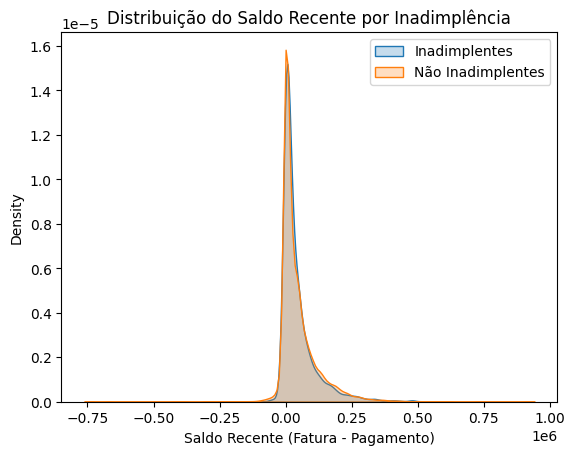

In [21]:
# Analisando o Saldo Recente por Inadimplência
sns.kdeplot(inad['saldo_recente'], label='Inadimplentes', fill=True)
sns.kdeplot(nao_inad['saldo_recente'], label='Não Inadimplentes', fill=True)
plt.title('Distribuição do Saldo Recente por Inadimplência')
plt.xlabel('Saldo Recente (Fatura - Pagamento)')
plt.legend()
plt.savefig('../imagens/distribuicao_saldo_recente_inadimplencia.png')
plt.show()